In [1]:
from typing import Optional
import sys
sys.path.append('/DATACENTER4/jiangbo.chai/SWJTU_OOPAO')
import gym
from gym import spaces
import numpy as np
import time
from OOPAO.Atmosphere import Atmosphere
from OOPAO.DeformableMirror import DeformableMirror
from OOPAO.Source import Source
from OOPAO.Telescope import Telescope
from OOPAO.ShackHartmann import ShackHartmann
from OOPAO.calibration.ao_calibration import ao_calibration
from tutorials.scao_system.myAoSystem.Imager import Imager
import matplotlib.pyplot as plt
import importlib
from collections import deque




     °          *      *      
 ▄██▄   ▄██▄  ▄███▄   ▄██▄ * ▄██▄ 
██* ██ ██  ██ ██  ██ ██  ██ ██  ██
██  ██ ██° ██ ██  ██ ██* ██ ██  ██
██  ██ ██  ██ ████▀  ██▄▄██ ██  ██
██* ██ ██  ██ ██     ██▀▀██ ██  ██
██  ██ ██  ██ ██ *   ██  ██ ██* ██
 ▀██▀   ▀██▀  ██   ° ██  ██  ▀██▀ 
      *         *             


**************************************************************************************************************************************************************
NUMPY WARNING: mkl blas not found! Multi-threading may not work as expected.
**************************************************************************************************************************************************************
1.26.2


In [2]:
def load_parameter_file(file_name):
    """动态加载指定参数文件"""
    try:
        module = importlib.import_module(f'paramsettings.{file_name}')
        return module.initializeParameterFile()
    except ImportError:
        raise ValueError(f"参数文件 {file_name} 不存在")
file_name = 'paramFile3'
param = load_parameter_file(file_name)
param

{'r0': 0.15,
 'L0': 30,
 'fractionnalR0': [0.7, 0.25, 0.05],
 'windSpeed': [5, 10, 20],
 'windDirection': [0, 90, 360],
 'altitude': [0, 4000, 10000],
 'resolution': 120,
 'diameter': 8,
 'sampling_rate': 1000,
 'centralObstruction': 0,
 'magnitude': 5,
 'opticalBand': 'H',
 'nSubap': 20,
 'mechCoupling': 0.1,
 'lightRatio': 0.3,
 'is_geometric': False,
 'threshold_cog': 0.01,
 'field_stop_size': 64,
 'nyquist_sampling': 4,
 'photonNoise': True,
 'readoutNoise': 20,
 'darkCurrent': 0.5,
 'nModes': 600,
 'name': 'VLT_H_band_20x20',
 'pathInput': 'data_calibration/',
 'pathOutput': 'data_cl/'}

In [16]:
sampling_rate=1000
exposure_time=1
clock_rate=1000
tel = Telescope(resolution=param['resolution'], 
                diameter=param['diameter'], 
                samplingTime=1/1000, 
                centralObstruction=param['centralObstruction'])
ngs = Source(magnitude=param['magnitude'],optBand=param['opticalBand'])
ngs * tel
atm = Atmosphere(telescope=tel, 
                        r0=param['r0'], 
                        L0=param['L0'], 
                        windSpeed=param['windSpeed'],
                        fractionalR0=param['fractionnalR0'], 
                        windDirection=param['windDirection'],
                        altitude=param['altitude'])

dm = DeformableMirror(telescope=tel, 
                            nSubap=param['nSubap'], 
                            mechCoupling=param['mechCoupling'])
wfs = ShackHartmann(nSubap=param['nSubap'], 
                            telescope=tel, 
                            lightRatio=0.6, 
                            is_geometric=param['is_geometric'], 
                            threshold_cog=param['threshold_cog'])
wfs.cam.photonNoise = param['photonNoise']
wfs.cam.readoutNoise = param['readoutNoise']
wfs.cam.darkCurrent = param['darkCurrent']

camH = Imager(exposure_time=exposure_time, clock_rate=clock_rate)

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% TELESCOPE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
     Diameter             8                [m]        
    Resolution           120             [pixels]     
    Pixel Size           0.07              [m]        
     Surface             50.0              [m2]       
Central Obstruction        0          [% of diameter]  
Pixels in the pupil      11304            [pixels]     
      Source             None                         
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No light propagated through the telescope
%%%%%%%%%%%%%%%%%%%%%%%%%%%%% SOURCE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
 Source Wavelength Zenith  Azimuth   Altitude Magnitude    Flux   
           [m]    [arcsec]  [deg]      [m]              [phot/m2/s]
-------------------------------------------------------------------
  NGS   1.654e-06    0        0        inf       5.0    29891304.3
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No coordinates load

In [17]:
ao_calib = ao_calibration(param=param, \
                        ngs=ngs, \
                        tel=tel, \
                        atm=atm, \
                        dm=dm, \
                        wfs=wfs, \
                        nameFolderIntMat=None, \
                        nameIntMat=None, \
                        nameFolderBasis=None, \
                        nameBasis=None, \
                        nMeasurements=100)
calib_CL = ao_calib.calib  # 交互矩阵
M2C_CL = ao_calib.M2C

Loading the KL Modal Basis from: data_calibration/M2C_120_res
ERROR: No file found! Taking a zonal basis instead..
Loading Interaction matrix data_calibration/VLT_H_band_20x20/zonal_interaction_matrix_120_res_308_subap_diffractive...
ERROR: No file found! computing imat..


Interaction Matrix Computation:


 25%|██▌       | 1/4 [00:03<00:09,  3.24s/it]

100/357
Time elapsed: 3.238466739654541 s


 50%|█████     | 2/4 [00:05<00:05,  2.92s/it]

...

 75%|███████▌  | 3/4 [00:08<00:02,  2.80s/it]

300/357
Time elapsed: 2.652590751647949 s


100%|██████████| 4/4 [00:09<00:00,  2.40s/it]

400/357
Time elapsed: 1.020660400390625 s


No Modal Gains found. All gains set to 1


In [18]:
from tutorials.scao_system.myAoSystem.Imager import Imager
atm.initializeAtmosphere(telescope=tel)

# 闭环控制
calib_CL    = ao_calib.calib # 交互矩阵
M2C_CL      = ao_calib.M2C 

tel+atm
ngs*tel*dm*wfs
# initialize DM commands
dm.coefs=0


param['nLoop'] = 200
# allocate memory to save data
SR                      = np.zeros(param['nLoop']) # 斯特列尔比
SR_old                      = np.zeros(param['nLoop'])
total                   = np.zeros(param['nLoop'])
residual                = np.zeros(param['nLoop'])
wfsSignal               = np.arange(0,wfs.nSignal)*0
# loop parameters
gainCL                  = 1  # 传感增益

for i in range(param['nLoop']):
    a=time.time()

    atm.update()

    tel-atm
    camH.relay(tel.src)
    camH.reference_frame = camH.frame
    tel+atm
    # 记录总的波前误差
    total[i]=np.std(tel.OPD[np.where(tel.pupil>0)])*1e9
    
    tel*dm*wfs

    dm.coefs=dm.coefs-gainCL*M2C_CL@calib_CL.M@wfsSignal
    
    wfsSignal=wfs.signal
    
    b= time.time()
    print('Elapsed time: ' + str(b-a) +' s')

    SR_old[i]=np.exp(-np.var(tel.src.phase[np.where(tel.pupil==1)]))  
    residual[i]=np.std(tel.OPD[np.where(tel.pupil>0)])*1e9
    camH.relay(tel.src)
    SR[i] = camH.strehl

    print('Loop'+str(i)+'/'+str(param['nLoop'])+' Turbulence: '+str(total[i])+' -- Residual:' +str(residual[i])+ '\n')


-> Computing the initial phase screen...
initial phase screen : 0.008509397506713867 s
ZZt.. : 1.5984671115875244 s
ZXt.. : 0.17791962623596191 s
XXt.. : 0.09169650077819824 s
Done!
-> Computing the initial phase screen...
initial phase screen : 0.006322145462036133 s
ZZt.. : 4.76837158203125e-07 s
ZXt.. : 1.9550323486328125e-05 s
XXt.. : 5.9604644775390625e-06 s
SCAO system considered: covariance matrices were already computed!
Done!
-> Computing the initial phase screen...
initial phase screen : 0.005994558334350586 s
ZZt.. : 1.430511474609375e-06 s
ZXt.. : 1.4781951904296875e-05 s
XXt.. : 5.4836273193359375e-06 s
SCAO system considered: covariance matrices were already computed!
Done!
Elapsed time: 0.05314135551452637 s
Loop0/200 Turbulence: 772.8947459831028 -- Residual:772.8947459831028

Elapsed time: 0.053330183029174805 s
Loop1/200 Turbulence: 773.6216211083824 -- Residual:773.6216211083824

Elapsed time: 0.060530900955200195 s
Loop2/200 Turbulence: 774.3584543952883 -- Residual

In [6]:
SR.mean()

0.07893915122207916

Text(0.5, 1.0, 'open loop')

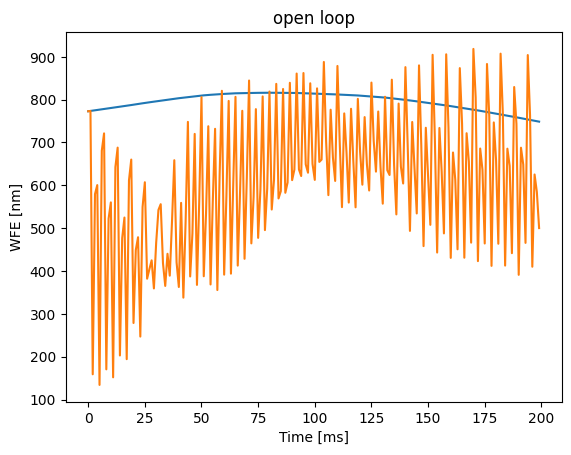

In [7]:
# 波前误差
plt.figure()
plt.plot(total)
plt.plot(residual)
plt.xlabel('Time [ms]')
plt.ylabel('WFE [nm]')
plt.title('open loop')


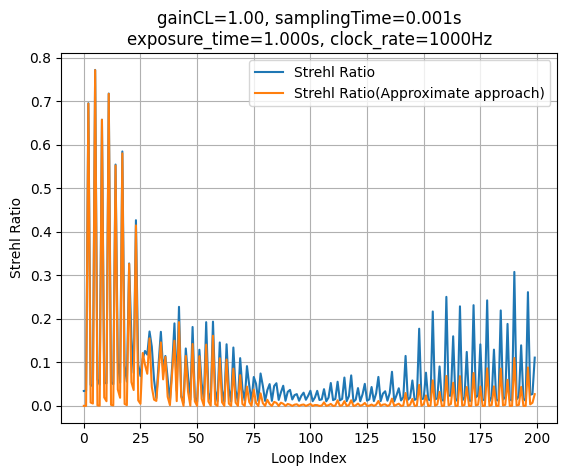

In [8]:
plt.figure()
plt.plot(np.arange(param['nLoop']), SR, label='Strehl Ratio')
plt.plot(np.arange(param['nLoop']), SR_old, label='Strehl Ratio(Approximate approach)')
plt.xlabel('Loop Index')
plt.ylabel('Strehl Ratio')
plt.title(  f"gainCL={gainCL:.2f}, "
            f"samplingTime={tel.samplingTime:.3f}s\n"
            f"exposure_time={camH.exposure_time:.3f}s, "
            f"clock_rate={camH.clock_rate:.0f}Hz")
plt.legend()
plt.grid()
plt.show()

In [9]:
from AdaptiveOpticsEnvR2DISC import AOEnv
from types import SimpleNamespace
sys.path.append('/DATACENTER4/jiangbo.chai/SWJTU_OOPAO/tutorials/scao_system/myAoSystem/RL4AO/agent/dreamerv3')

args = SimpleNamespace(
    agent = "PPO",
    episodes = 10,
    seed = 0,
    maxStep = 200,
    gainCL = 0.6,
    samplingRate = 1000,
    exposureTime = 1,
    clockRate = 1000,
    lightRatio = 0.6,
    paramFile = "paramFile3",  
    k = 3,
    delay=0
)

# 创建环境
env = AOEnv(args)


%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% TELESCOPE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
     Diameter             8                [m]        
    Resolution           120             [pixels]     
    Pixel Size           0.07              [m]        
     Surface             50.0              [m2]       
Central Obstruction        0          [% of diameter]  
Pixels in the pupil      11304            [pixels]     
      Source             None                         
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No light propagated through the telescope
%%%%%%%%%%%%%%%%%%%%%%%%%%%%% SOURCE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
 Source Wavelength Zenith  Azimuth   Altitude Magnitude    Flux   
           [m]    [arcsec]  [deg]      [m]              [phot/m2/s]
-------------------------------------------------------------------
  NGS   1.654e-06    0        0        inf       5.0    29891304.3
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No coordinates load

Loading the KL Modal Basis from: data_calibration/M2C_120_res
ERROR: No file found! Taking a zonal basis instead..
Loading Interaction matrix data_calibration/VLT_H_band_20x20/zonal_interaction_matrix_120_res_308_subap_diffractive...
ERROR: No file found! computing imat..
Interaction Matrix Computation:


 25%|██▌       | 1/4 [00:01<00:05,  1.77s/it]

100/357
Time elapsed: 1.7737178802490234 s


 50%|█████     | 2/4 [00:03<00:03,  1.58s/it]

...

 75%|███████▌  | 3/4 [00:04<00:01,  1.47s/it]

300/357
Time elapsed: 1.342649221420288 s


100%|██████████| 4/4 [00:05<00:00,  1.31s/it]

400/357
Time elapsed: 0.6838893890380859 s


No Modal Gains found. All gains set to 1


In [10]:
def _calculate_reward(action):
    """优化奖励函数（新增湍流惩罚）"""
    # 基础奖励（保持原有计算方式）
    # 解包动作参数
    gain, sample_freq, exposure, clock_freq = action
    reward=0

    # 约束1: 曝光时间↑ → 增益↓ (反向关系约束)
    # 理想比例：曝光时间占最大值时，增益应接近最小值
    gain_penalty = np.abs(gain - (1.0 - 0.9 * (exposure - 0.1) / 0.9))  # 线性惩罚项
    reward -= 0.2 * gain_penalty  # 比例系数可调

    # 约束2: 采样频率↑ → 增益↑ (正向关系约束)
    # 理想比例：采样频率2000Hz时增益应接近1.0，100Hz时接近0.1
    desired_gain = 0.1 + 0.9 * (sample_freq - 100) / 1900
    freq_gain_penalty = np.abs(gain - desired_gain)
    reward -= 0.2 * freq_gain_penalty

    # 约束3: 曝光时间↑ → 采样频率↓ (反向关系约束)
    # 限制曝光时间×采样频率的乘积不超过阈值（如500）
    freq_exposure_penalty = max(0, (exposure * sample_freq - 500) / 500)
    reward -= 0.5 * freq_exposure_penalty  # 强惩罚越界行为

    # 约束4: 时钟频率↑ → 曝光时间↓ (反向关系约束)
    # 理想关系：曝光时间 ∝ 1/clock_freq
    desired_exposure = 1.0 / (clock_freq / 500)  # 基准值500Hz时曝光1.0
    clock_penalty = np.abs(exposure - desired_exposure)
    reward -= 0.3 * clock_penalty        
    
    # # 新增时序同步惩罚（保持原有逻辑）
    # tel_freq, cam_freq = action[1], action[3]
    # if abs(tel_freq - cam_freq) > 100:
    #     reward -= 1

        
    return reward

In [19]:
# 记录所有 gain 下的平均 SR
average_SR_list = []
return_list = []
# 扫描所有 gain index
sampling_rate=1000
exposure_time=0.5
clock_rate=1000
for gain_index in range(env.gain_dim):
    atm.initializeAtmosphere(telescope=tel)
    dm.coefs=0
    wfsSignal=np.arange(0,wfs.nSignal)*0
    tel+atm
    ngs*tel*dm*wfs
    param['nLoop'] = 200
    gainCL = env.gain_values[gain_index]
    SR_list = []
    episode_return = 0

    for i in range(param['nLoop']):

        atm.update()

        tel-atm
        camH.relay(tel.src)
        camH.reference_frame = camH.frame
        tel+atm
        tel*dm*wfs

        dm.coefs=dm.coefs-gainCL*M2C_CL@calib_CL.M@wfsSignal
        
        wfsSignal=wfs.signal
        camH.relay(tel.src)
        SR_list.append(camH.strehl)
        residual_i=np.std(tel.OPD[np.where(tel.pupil>0)])*1e9

        # 计算奖励
        """将WFE压缩到[0,1]范围，100nm为0.5，两端渐进饱和"""
        normalized_wfe = 0.5 * (np.tanh((residual_i - 100) / 300) + 1)  # 300控制斜率
        if residual_i < 100:     # 波前误差<100:超高性能奖励
            reward = camH.strehl + (1 - normalized_wfe)
        else:
            reward = camH.strehl - 0.3 * normalized_wfe
        episode_return+=(reward+_calculate_reward(np.array([gainCL,sampling_rate,exposure_time,clock_rate])))
        

    avg_SR = np.mean(SR_list)
    average_SR_list.append(avg_SR)
    return_list.append(episode_return)



    # 如果需要，打印每次结果
    print(f"Gain index {gain_index}, gain value {gainCL:.2f}, Average SR: {avg_SR:.4f},episode_return: {episode_return:.2f}")

Gain index 0, gain value 0.10, Average SR: 0.6163,episode_return: 46.62
Gain index 1, gain value 0.15, Average SR: 0.6344,episode_return: 54.52
Gain index 2, gain value 0.20, Average SR: 0.6380,episode_return: 59.23
Gain index 3, gain value 0.25, Average SR: 0.6401,episode_return: 63.62
Gain index 4, gain value 0.30, Average SR: 0.6393,episode_return: 67.40
Gain index 5, gain value 0.35, Average SR: 0.6384,episode_return: 71.17
Gain index 6, gain value 0.40, Average SR: 0.6369,episode_return: 74.78
Gain index 7, gain value 0.45, Average SR: 0.6351,episode_return: 78.36
Gain index 8, gain value 0.50, Average SR: 0.6341,episode_return: 82.09
Gain index 9, gain value 0.55, Average SR: 0.6326,episode_return: 83.83
Gain index 10, gain value 0.60, Average SR: 0.6294,episode_return: 83.07
Gain index 11, gain value 0.65, Average SR: 0.6258,episode_return: 78.25
Gain index 12, gain value 0.70, Average SR: 0.6231,episode_return: 73.61
Gain index 13, gain value 0.75, Average SR: 0.6171,episode_re

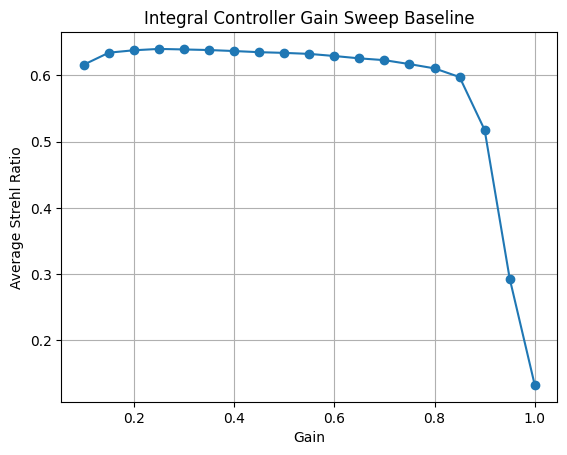

In [20]:
plt.figure()
plt.plot(env.gain_values, average_SR_list, marker='o')
plt.xlabel('Gain')
plt.ylabel('Average Strehl Ratio')
plt.title('Integral Controller Gain Sweep Baseline')
plt.grid()
plt.show()

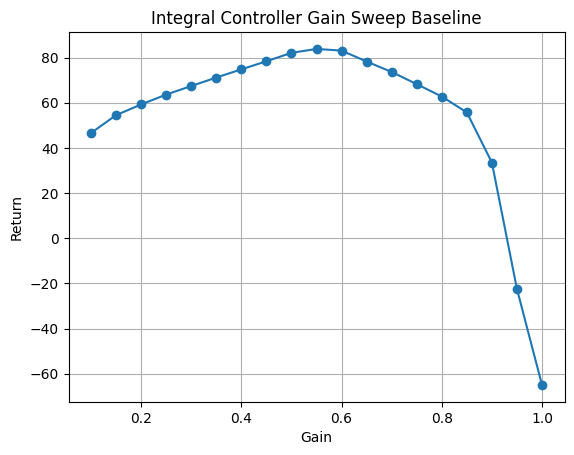

In [21]:
plt.figure()
plt.plot(env.gain_values, return_list, marker='o')
plt.xlabel('Gain')
plt.ylabel('Return')
plt.title('Integral Controller Gain Sweep Baseline')
plt.grid()
plt.show()

In [24]:
print(max(average_SR_list),max(return_list))

0.6400573142921044 83.82685034987213


In [14]:
import numpy as np

# 加载 .npz 文件
data = np.load("../logdir/AO1_R2DISC_lightRatio0.6_param4/train_eps/20250830T164542-48ff1945a85b498a97c62c8f7be746e9-201.npz")

# 查看文件中包含的数组名称
print("文件中的数组键名:", list(data.keys()))

# 提取数据（假设文件中有一个名为 'arr_0' 的数组）
action = data["action"]  # 根据实际键名调整
print(action.shape)
reward = data["reward"]
print(reward.shape)

FileNotFoundError: [Errno 2] No such file or directory: '../logdir/AO1_R2DISC_lightRatio0.6_param4/train_eps/20250830T164542-48ff1945a85b498a97c62c8f7be746e9-201.npz'

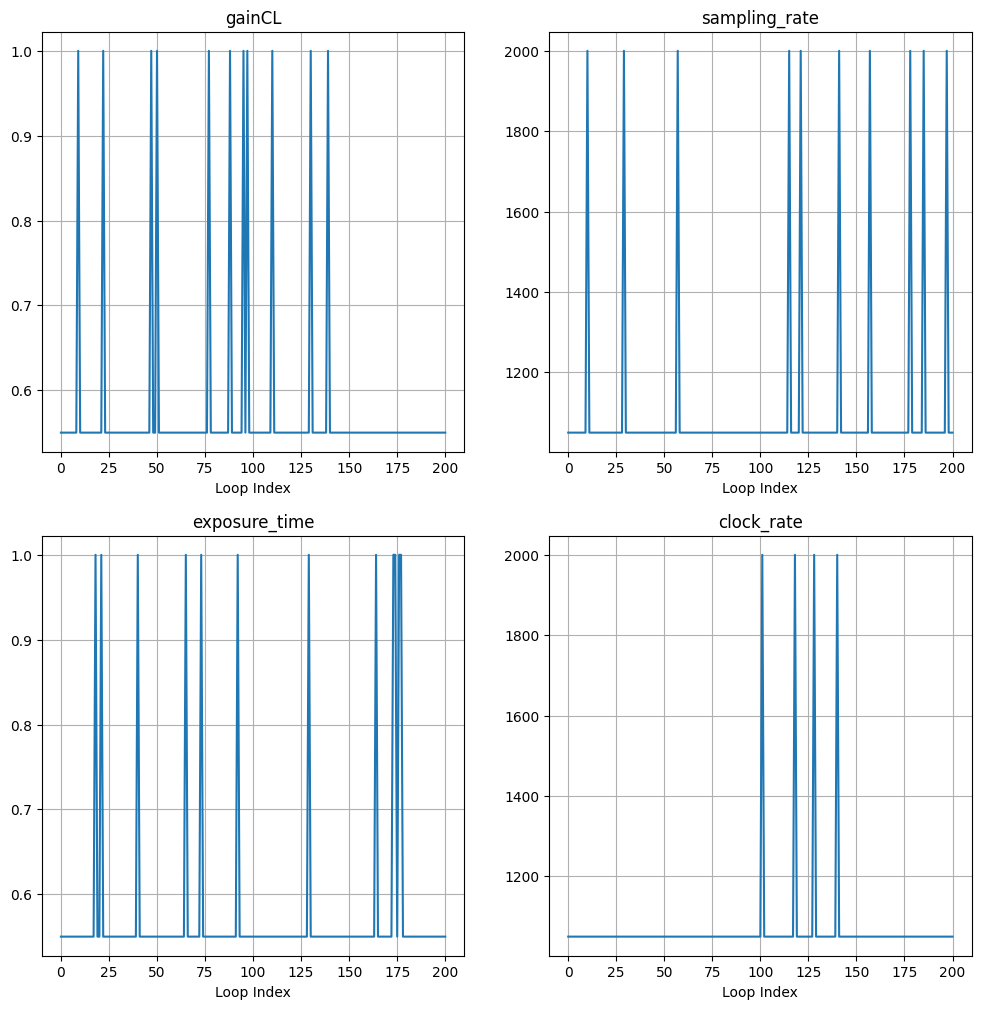

In [ ]:
def step(action):
    action1 = (action[:,0] + 1) / 2 * (1 - 0.1) + 0.1
    action2 = (action[:,1] + 1) / 2 * (2000 - 100) + 100
    action3 = (action[:,2] + 1) / 2 * (1 - 0.1) + 0.1
    action4 = (action[:,3] + 1) / 2 * (2000 - 100) + 100

    return action1,action2,action3,action4

action1,action2,action3,action4 = step(action)


plt.figure(figsize=(12,12))
    
plt.subplot(221)
plt.plot(action1)
plt.title("gainCL")
plt.xlabel("Loop Index")
plt.grid()

plt.subplot(222)
plt.plot(action2)
plt.title("sampling_rate")
plt.xlabel("Loop Index")
plt.grid()

plt.subplot(223)
plt.plot(action3)
plt.title("exposure_time")
plt.xlabel("Loop Index")
plt.grid()

plt.subplot(224)
plt.plot(action4)
plt.title("clock_rate")
plt.xlabel("Loop Index")
plt.grid()

In [ ]:
action1

array([0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 1.  , 0.55,
       0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55,
       1.  , 0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55,
       0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55,
       0.55, 0.55, 0.55, 1.  , 0.55, 0.55, 1.  , 0.55, 0.55, 0.55, 0.55,
       0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55,
       0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55,
       1.  , 0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55,
       1.  , 0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 1.  , 0.55, 1.  , 0.55,
       0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55,
       1.  , 0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55,
       0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 1.  , 0.55,
       0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 1.  , 0.55, 0.55, 0.55,
       0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.